# Exploratory Data Analysis

## About the dataset

- Exploratory Dataset: 22,666 packages from 4,873 experiments for exploration and development.
- Confirmatory Dataset: 105,551 additional packages from 22,743 experiments to train and test hypotheses.
- Holdout Dataset: Extra dataset to validate the results in case that Confirmatory Dataset has been used to define the hypothesis.

In simple data science terms:
- Training: Exploratory Dataset
- Validation: Confirmatory Dataset
- Testing: Holdout Dataset

Properties of the dataset:
- Each record is called a `package`. It involves a headline and eyecatcher picture shown to the user.
- The `test` contains a set of packages. Packages are randomly assigned to the users as part of the A/B test. Tests are identified by the `clickability_test_id`

Datasets are a random sample stratified by week number. This means the week has been used for a randomization that reduce the week as a confounding factor.

**tests**

Columns:
- `created_at`: Date and time when the package was created
- `test_week`: Created by archive creators for week stratification
- `clickability_test_id`: Unique identifier for the test, the specific headline and eyecatcher picture
- `impressions`: Number of times the package was shown to users
- `clicks`: Number of times the package was clicked
- `headline`: The headline text shown to the user
- `eyecatcher_url`: The URL of the eyecatcher picture
- Information of interest but not shown to the user:
  - `excerpt`: article excerpt
  - `lede`: the opening sentence or paragraph of the story
  - `slug`: internal name for the web address
  - `share_text`: summary for display on social media when the article is shared
- Fields completed by Upworthy staff:
  - `square`: part of the same social media sharing suggestion
  - `significance`: NOT an estimate of statistical significance
  - `first_place`: Shown to editors to guide decisions about what test to choose
  - `winner`: Whether a package was selected by editors to be used on the Upworthy site after the test
  - `updated_at`: The last time the package was updated in the Upworthy system

The only fields we'll care about are `created_at`, `test_week`, `clickability_test_id`, `impressions`, `clicks`, `headline`, `eyecatcher_url`, `first_place`, `winner`.

## Load the dataset

In [46]:
import pandas as pd

exploratory_dataset_path = "dataset/upworthy-archive-datasets/upworthy-archive-exploratory-packages-03.12.2020.csv"
confirmatory_dataset_path = "dataset/upworthy-archive-datasets/upworthy-archive-confirmatory-packages-03.12.2020.csv"
holdout_dataset_path = "dataset/upworthy-archive-datasets/upworthy-archive-holdout-packages-03.12.2020.csv"

exploratory_df = pd.read_csv(exploratory_dataset_path)
confirmatory_df = pd.read_csv(confirmatory_dataset_path)
holdout_df = pd.read_csv(holdout_dataset_path)

exploratory_df.head()

/var/folders/fw/s4mlw4vx2hx944qtl0q1vcfm0000gn/T/ipykernel_88392/139308962.py:8: DtypeWarning: Columns (15) have mixed types. Specify dtype option on import or set low_memory=False.
  confirmatory_df = pd.read_csv(confirmatory_dataset_path)


,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week
0,0,2014-11-20 06:43:16.005,2016-04-02 16:33:38.062,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3052,150,100.0,True,True,Anyone who's ever felt guilty about shopping a...,NaN,201446
1,1,2014-11-20 06:43:44.646,2016-04-02 16:25:54.021,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3033,122,14.0,False,False,Walmart is getting schooled by another retaile...,NaN,201446
2,2,2014-11-20 06:44:59.804,2016-04-02 16:25:54.024,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3092,110,1.8,False,False,Walmart may not be crapping their pants over t...,NaN,201446
3,3,2014-11-20 06:54:36.335,2016-04-02 16:25:54.027,546d902c26714c6c44000039,Things that matter. Pass 'em on.,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,this-is-what-sexism-against-men-sounds-like-am...,546bc55335992b86c8000043,3526,90,4.1,False,False,"If you ever wondered, ""but what about the men?...",NaN,201446
4,4,2014-11-20 06:54:57.878,2016-04-02 16:31:45.671,546d902c26714c6c44000039,Things that matter. Pass 'em on.,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,this-is-what-sexism-against-men-sounds-like-am...,546d900426714cd2dd00002e,3506,120,100.0,True,False,"If you ever wondered, ""but what about the men?...",NaN,201446


In [47]:
exploratory_df.describe()

,Unnamed: 0,impressions,clicks,significance,test_week
count,22666.000000,22666.000000,22666.000000,22666.000000,22666.000000
mean,75219.085370,3574.700035,54.319598,40.733826,201417.975382
std,43728.705113,1437.948530,46.839176,39.670098,56.344639
min,0.000000,13.000000,0.000000,0.000000,201303.000000
25%,37068.250000,2740.000000,24.000000,2.800000,201402.000000
50%,74987.500000,3122.000000,42.000000,25.700000,201430.000000
75%,112952.750000,4091.000000,70.000000,85.400000,201444.000000
max,150816.000000,25314.000000,975.000000,100.000000,201517.000000


From the describe we can see the dataset has 22,666 packages as expected. The mean of impressions is **3,574** and the std is **1,437** which is a high variance but as much as I expected.

The mean number of clicks per package also has a high variance. The significance is not considered.

### Calculate CTR

I'll calculate the CTR for each package and print the mean and std.

In [48]:
exploratory_df['ctr'] = exploratory_df['clicks'] / exploratory_df['impressions']
confirmatory_df['ctr'] = confirmatory_df['clicks'] / confirmatory_df['impressions']
holdout_df['ctr'] = holdout_df['clicks'] / holdout_df['impressions']

print(f"Mean CTR: {exploratory_df['ctr'].mean()}")
print(f"Std of CTR: {exploratory_df['ctr'].std()}")

Mean CTR: 0.015754479894441
Std of CTR: 0.012288723628223438


I expected the CTR to be more stable but it has a high variance too. This adds more richness to the dataset and the analysis.

In [49]:
exploratory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22666 entries, 0 to 22665
Data columns (total 18 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            22666 non-null  int64  
 1   created_at            22666 non-null  object 
 2   updated_at            22666 non-null  object 
 3   clickability_test_id  22666 non-null  object 
 4   excerpt               20249 non-null  object 
 5   headline              22666 non-null  object 
 6   lede                  22654 non-null  object 
 7   slug                  22666 non-null  object 
 8   eyecatcher_id         22644 non-null  object 
 9   impressions           22666 non-null  int64  
 10  clicks                22666 non-null  int64  
 11  significance          22666 non-null  float64
 12  first_place           22666 non-null  bool   
 13  winner                22666 non-null  bool   
 14  share_text            3208 non-null   object 
 15  square             

### De-mean the CTR

In [50]:
# First calculate mean and std CTR for each Test group
exploratory_df['avg_test_ctr'] = exploratory_df.groupby('clickability_test_id')['ctr'].transform('mean')
exploratory_df['std_test_ctr'] = exploratory_df.groupby('clickability_test_id')['ctr'].transform('std')

confirmatory_df['avg_test_ctr'] = confirmatory_df.groupby('clickability_test_id')['ctr'].transform('mean')
confirmatory_df['std_test_ctr'] = confirmatory_df.groupby('clickability_test_id')['ctr'].transform('std')

holdout_df['avg_test_ctr'] = holdout_df.groupby('clickability_test_id')['ctr'].transform('mean')
holdout_df['std_test_ctr'] = holdout_df.groupby('clickability_test_id')['ctr'].transform('std')

# De-meaned CTR (Adjusted by variance too)
exploratory_df['ctr_demeaned'] = (exploratory_df['ctr'] - exploratory_df['avg_test_ctr']) / exploratory_df['std_test_ctr']
confirmatory_df['ctr_demeaned'] = (confirmatory_df['ctr'] - confirmatory_df['avg_test_ctr']) / confirmatory_df['std_test_ctr']
holdout_df['ctr_demeaned'] = (holdout_df['ctr'] - holdout_df['avg_test_ctr']) / holdout_df['std_test_ctr']

# Clean up to retain only relevant columns
exploratory_df.drop(columns=['avg_test_ctr', 'std_test_ctr'], inplace=True)
confirmatory_df.drop(columns=['avg_test_ctr', 'std_test_ctr'], inplace=True)
holdout_df.drop(columns=['avg_test_ctr', 'std_test_ctr'], inplace=True)


In [51]:
exploratory_df.head()

,Unnamed: 0,created_at,updated_at,clickability_test_id,excerpt,headline,lede,slug,eyecatcher_id,impressions,clicks,significance,first_place,winner,share_text,square,test_week,ctr,ctr_demeaned
0,0,2014-11-20 06:43:16.005,2016-04-02 16:33:38.062,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3052,150,100.0,True,True,Anyone who's ever felt guilty about shopping a...,NaN,201446,0.049148,1.218048
1,1,2014-11-20 06:43:44.646,2016-04-02 16:25:54.021,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3033,122,14.0,False,False,Walmart is getting schooled by another retaile...,NaN,201446,0.040224,-0.339955
2,2,2014-11-20 06:44:59.804,2016-04-02 16:25:54.024,546d88fb84ad38b2ce000024,Things that matter. Pass 'em on.,They're Being Called 'Walmart's Worst Nightmar...,"<p>When I saw *why* people are calling them ""W...",theyre-being-called-walmarts-worst-nightmare-a...,546d6fa19ad54eec8d00002d,3092,110,1.8,False,False,Walmart may not be crapping their pants over t...,NaN,201446,0.035576,-1.151530
3,3,2014-11-20 06:54:36.335,2016-04-02 16:25:54.027,546d902c26714c6c44000039,Things that matter. Pass 'em on.,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,this-is-what-sexism-against-men-sounds-like-am...,546bc55335992b86c8000043,3526,90,4.1,False,False,"If you ever wondered, ""but what about the men?...",NaN,201446,0.025525,-0.164895
4,4,2014-11-20 06:54:57.878,2016-04-02 16:31:45.671,546d902c26714c6c44000039,Things that matter. Pass 'em on.,This Is What Sexism Against Men Sounds Like,<p>DISCLOSURE: I'm a dude. I have cried on mul...,this-is-what-sexism-against-men-sounds-like-am...,546d900426714cd2dd00002e,3506,120,100.0,True,False,"If you ever wondered, ""but what about the men?...",NaN,201446,0.034227,2.002963


The fields that matter for us don't have missing values. Only some eyecatcher_ids but this won't be used for now.

In [52]:
columns_to_keep = [
    'Unnamed: 0',
    'created_at',
    'test_week',
    'clickability_test_id',
    'headline',
    'eyecatcher_id',
    'impressions',
    'clicks',
    'ctr',
    'ctr_demeaned',
    'first_place',
    'winner'
]

# Subset and rename the ID column
exploratory_df = exploratory_df[columns_to_keep].rename(columns={'Unnamed: 0': 'package_id'})
confirmatory_df = confirmatory_df[columns_to_keep].rename(columns={'Unnamed: 0': 'package_id'})
holdout_df = holdout_df[columns_to_keep].rename(columns={'Unnamed: 0': 'package_id'})

exploratory_df.head()


,package_id,created_at,test_week,clickability_test_id,headline,eyecatcher_id,impressions,clicks,ctr,ctr_demeaned,first_place,winner
0,0,2014-11-20 06:43:16.005,201446,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,546d6fa19ad54eec8d00002d,3052,150,0.049148,1.218048,True,True
1,1,2014-11-20 06:43:44.646,201446,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,546d6fa19ad54eec8d00002d,3033,122,0.040224,-0.339955,False,False
2,2,2014-11-20 06:44:59.804,201446,546d88fb84ad38b2ce000024,They're Being Called 'Walmart's Worst Nightmar...,546d6fa19ad54eec8d00002d,3092,110,0.035576,-1.151530,False,False
3,3,2014-11-20 06:54:36.335,201446,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,546bc55335992b86c8000043,3526,90,0.025525,-0.164895,False,False
4,4,2014-11-20 06:54:57.878,201446,546d902c26714c6c44000039,This Is What Sexism Against Men Sounds Like,546d900426714cd2dd00002e,3506,120,0.034227,2.002963,True,False


In [53]:
# Store in the processed folder
exploratory_df.to_csv("dataset/processed/exploratory-packages.csv", index=False)
confirmatory_df.to_csv("dataset/processed/confirmatory-packages.csv", index=False)
holdout_df.to_csv("dataset/processed/holdout-packages.csv", index=False)


## Analyze Test and Packages

The dataset is supposed to contain 4,873 tests and 22,666 packages.

In [54]:
# Print the number of unique "clickability_test_id"
print(f"Exploratory Unique Tests: {exploratory_df['clickability_test_id'].nunique()}")
print(f"Confirmatory Unique Tests: {confirmatory_df['clickability_test_id'].nunique()}")
print(f"Holdout Unique Tests: {holdout_df['clickability_test_id'].nunique()}")



Exploratory Unique Tests: 4873
Confirmatory Unique Tests: 22743
Holdout Unique Tests: 4871


I want to have an idea of the average number of packages per test.

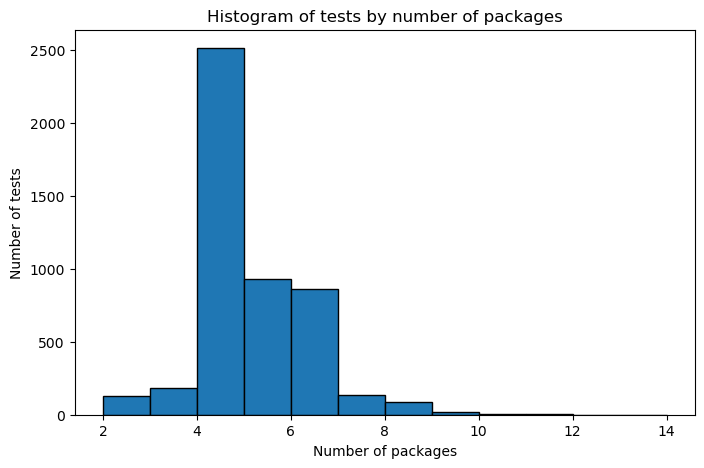

In [55]:
import matplotlib.pyplot as plt

# Group the number of packages per test
packages_per_test = exploratory_df.groupby('clickability_test_id')['package_id'].nunique()

plt.figure(figsize=(8, 5))
plt.hist(packages_per_test, bins=range(packages_per_test.min(), packages_per_test.max() + 1), edgecolor='black')
plt.xlabel('Number of packages')
plt.ylabel('Number of tests')
plt.title('Histogram of tests by number of packages')
plt.show()

Most of the tests have 4 packages, many have 5 or 6. Some have 2, 3, 7, 8, or 9. There are tests with up to 14 packages, but these may be exceptions.

I've seen some tests with packages where the headline is the same but eyecatcher is different. I want to differentiate them by four categories:
- Equal headline, equal eyecatcher
- Equal headline, different eyecatcher
- Different headline, equal eyecatcher
- Different headline, different eyecatcher

In [56]:
import numpy as np

# Classify the Tests into 4 groups based on headlines and eyecatchers

# Using the aggregate function to calculate the number of unique headlines and eyecatchers per test
tests_summary = exploratory_df.groupby('clickability_test_id').agg(
    n_headlines=('headline', 'nunique'),
    n_eyecatchers=('eyecatcher_id', 'nunique')
).reset_index()


conditions = [
    (tests_summary['n_headlines'] == 1) & (tests_summary['n_eyecatchers'] == 1),
    (tests_summary['n_headlines'] == 1) & (tests_summary['n_eyecatchers'] > 1),
    (tests_summary['n_headlines'] > 1) & (tests_summary['n_eyecatchers'] == 1),
    (tests_summary['n_headlines'] > 1) & (tests_summary['n_eyecatchers'] > 1),
    (tests_summary['n_headlines'] > 1)
]

# Filter tests_symmary based on the conditions
print(f"Nr of tests = headline and = eyecatcher: {tests_summary[conditions[0]].shape[0]}")
print(f"Nr of tests = headline and != eyecatcher: {tests_summary[conditions[1]].shape[0]}")
print(f"Nr of tests != headline and = eyecatcher: {tests_summary[conditions[2]].shape[0]}")
print(f"Nr of tests != headline and != eyecatcher: {tests_summary[conditions[3]].shape[0]}")
print(f"Nr of tests != headline: {tests_summary[conditions[4]].shape[0]}")



Nr of tests = headline and = eyecatcher: 838
Nr of tests = headline and != eyecatcher: 1426
Nr of tests != headline and = eyecatcher: 2304
Nr of tests != headline and != eyecatcher: 300
Nr of tests != headline: 2607


Only 2607 of the 4873 tests have more than one different headline. I'll only keep those.

I'm not interested in the ones with the same headline and different eyecatcher because the "catchyness" of the headline depends more on the image which I cannot access.

The tests where the headline and eyecatcher are all the same may be for a different type of A/B test done by Upworthy, where they want to evaluate other metadata and not the headline.

In [57]:
print(f"Exploratory: Nr of tests before filtering: {exploratory_df['clickability_test_id'].nunique()}")
print(f"Exploratory: Nr of packages before filtering: {exploratory_df.shape[0]}")
exploratory_headlines_per_test = exploratory_df.groupby('clickability_test_id').agg(n_headlines=('headline', 'nunique')).reset_index()
exploratory_headlines_per_test = exploratory_headlines_per_test[exploratory_headlines_per_test['n_headlines'] > 1]
exploratory_df = exploratory_df[exploratory_df['clickability_test_id'].isin(exploratory_headlines_per_test['clickability_test_id'])]
print(f"Exploratory: Nr of tests after filtering: {exploratory_df['clickability_test_id'].nunique()}")
print(f"Exploratory: Nr of packages after filtering: {exploratory_df.shape[0]}")

print(f"Confirmatory: Nr of tests before filtering: {confirmatory_df['clickability_test_id'].nunique()}")
print(f"Confirmatory: Nr of packages before filtering: {confirmatory_df.shape[0]}")
confirmatory_headlines_per_test = confirmatory_df.groupby('clickability_test_id').agg(n_headlines=('headline', 'nunique')).reset_index()
confirmatory_headlines_per_test = confirmatory_headlines_per_test[confirmatory_headlines_per_test['n_headlines'] > 1]
confirmatory_df = confirmatory_df[confirmatory_df['clickability_test_id'].isin(confirmatory_headlines_per_test['clickability_test_id'])]
print(f"Confirmatory: Nr of tests after filtering: {confirmatory_df['clickability_test_id'].nunique()}")
print(f"Confirmatory: Nr of packages after filtering: {confirmatory_df.shape[0]}")

print(f"Holdout: Nr of tests before filtering: {holdout_df['clickability_test_id'].nunique()}")
print(f"Holdout: Nr of packages before filtering: {holdout_df.shape[0]}")
holdout_headlines_per_test = holdout_df.groupby('clickability_test_id').agg(n_headlines=('headline', 'nunique')).reset_index()
holdout_headlines_per_test = holdout_headlines_per_test[holdout_headlines_per_test['n_headlines'] > 1]
holdout_df = holdout_df[holdout_df['clickability_test_id'].isin(holdout_headlines_per_test['clickability_test_id'])]
print(f"Holdout: Nr of tests after filtering: {holdout_df['clickability_test_id'].nunique()}")
print(f"Holdout: Nr of packages after filtering: {holdout_df.shape[0]}")


exploratory_df.to_csv("dataset/processed/exploratory-packages-diff-headlines.csv", index=False)
confirmatory_df.to_csv("dataset/processed/confirmatory-packages-diff-headlines.csv", index=False)
holdout_df.to_csv("dataset/processed/holdout-packages-diff-headlines.csv", index=False)


Exploratory: Nr of tests before filtering: 4873
Exploratory: Nr of packages before filtering: 22666
Exploratory: Nr of tests after filtering: 2607
Exploratory: Nr of packages after filtering: 12010
Confirmatory: Nr of tests before filtering: 22743
Confirmatory: Nr of packages before filtering: 105551
Confirmatory: Nr of tests after filtering: 12495
Confirmatory: Nr of packages after filtering: 57413
Holdout: Nr of tests before filtering: 4871
Holdout: Nr of packages before filtering: 22600
Holdout: Nr of tests after filtering: 2700
Holdout: Nr of packages after filtering: 12474


Plot the histogram of CTR per package.

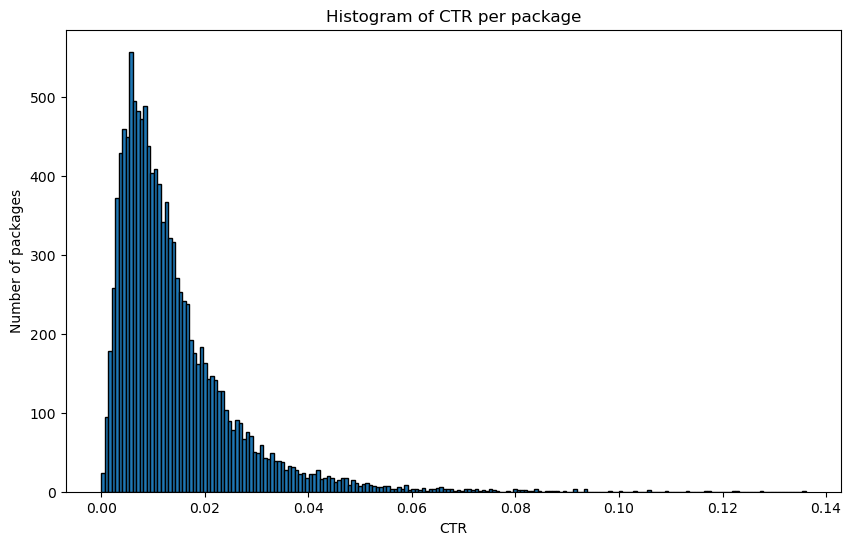

In [58]:
# Plot the histogram of CTR per package
plt.figure(figsize=(10, 6))
plt.hist(exploratory_df['ctr'], bins=200, edgecolor='black')
plt.xlabel('CTR')
plt.ylabel('Number of packages')
plt.title('Histogram of CTR per package')
plt.show()

There doesn't seem to be a huge difference in the CTR between different packages.

Now I'll plot the histogram of the de-meaned CTR per package.

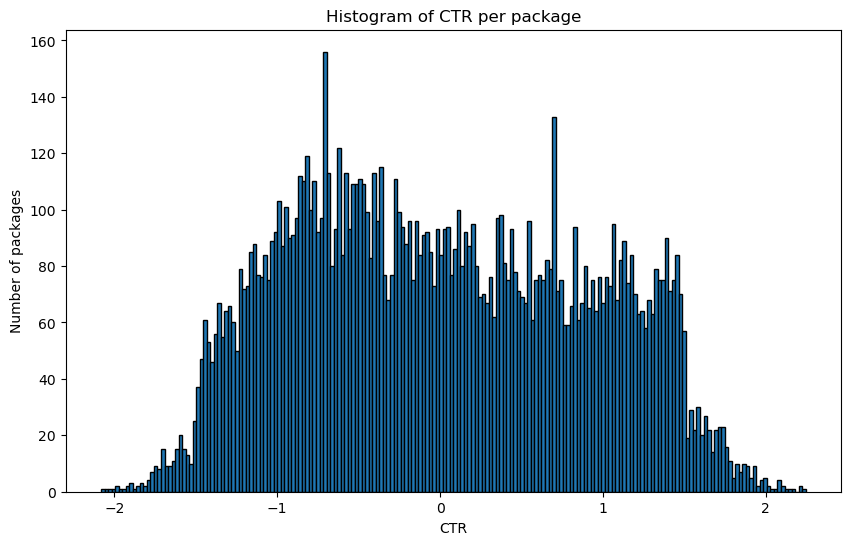

In [59]:
# Plot the histogram of CTR per package
plt.figure(figsize=(10, 6))
plt.hist(exploratory_df['ctr_demeaned'], bins=200, edgecolor='black')
plt.xlabel('CTR')
plt.ylabel('Number of packages')
plt.title('Histogram of CTR per package')
plt.show()

If the headlines didn't matter, all the values should be around 0, but as we can see, there are certain headlines that perform better than others in the same test, and there other that perform worse.

The total positive values of the de-meaned CTR should be equal to the total negative ones.

## Understand first_place and winner

The dataset defines these columns as:
- `first_place`: Shown to editors to guide decisions about what test to choose
- `winner`: Whether a package was selected by editors to be used on the Upworthy site after the test

But from my point of view, the winner should be the package with the highest CTR.

In [60]:
# Add a feature to verify if the package has the highest CTR in the test
max_ctr_per_test = exploratory_df.groupby('clickability_test_id')['ctr'].transform('max')
exploratory_df['is_highest_ctr'] = exploratory_df['ctr'] == max_ctr_per_test

# df.head()

# First filter by the ones that has the flag first_place, for those get the is_highest_ctr feature, and calculate the mean
highest_ctr_among_first_place = exploratory_df.loc[exploratory_df['first_place'], 'is_highest_ctr'].mean()
highest_ctr_among_winner = exploratory_df.loc[exploratory_df['winner'], 'is_highest_ctr'].mean()

# Now do the opposite
first_place_among_highest_ctr = exploratory_df.loc[exploratory_df['is_highest_ctr'], 'first_place'].mean()
winner_among_highest_ctr = exploratory_df.loc[exploratory_df['is_highest_ctr'], 'winner'].mean()

print("Percentage of first_place packages that are highest CTR:", highest_ctr_among_first_place)
print("Percentage of winner packages that are highest CTR:", highest_ctr_among_winner)
print("Percentage of highest-CTR packages marked first_place:", first_place_among_highest_ctr)
print("Percentage of highest-CTR packages marked winner:", winner_among_highest_ctr)

# pd.crosstab(df['is_highest_ctr'], df['first_place'], margins=True, normalize='index')
# pd.crosstab(df['is_highest_ctr'], df['winner'], margins=True, normalize='index')


Percentage of first_place packages that are highest CTR: 0.8944918541505043
Percentage of winner packages that are highest CTR: 0.7974683544303798
Percentage of highest-CTR packages marked first_place: 0.8845416187188339
Percentage of highest-CTR packages marked winner: 0.14499424626006904


This looks like most of the time the editors didn't select the package with the highest CTR as the winner, only 17% of the times. In reality, it seems not many packages have the winner flag set to true.

In [61]:
print(f"Nr of 'winner': {exploratory_df['winner'].sum()}")
print(f"Nr of 'first_place': {exploratory_df['first_place'].sum()}")
print(f"Nr of 'is_highest_ctr': {exploratory_df['is_highest_ctr'].sum()}")

Nr of 'winner': 474
Nr of 'first_place': 2578
Nr of 'is_highest_ctr': 2607


We can relatively rely on the "first_place" flag, but not on the "winner" flag. A package of the tests is selected as a winner in a low part of the tests.

In [62]:
# Saving processed dataset with highest CTR flag
exploratory_df.to_csv("dataset/processed/exploratory-packages-highest-ctr.csv", index=False)
confirmatory_df.to_csv("dataset/processed/confirmatory-packages-highest-ctr.csv", index=False)
holdout_df.to_csv("dataset/processed/holdout-packages-highest-ctr.csv", index=False)
